# Bluesky Data Science
## Part 10 - Real-Time Streams and Bots

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Background

> **tl;dr**: Every previous part of this series queried the *past*: we asked the API for posts, follows, and likes that already existed. ATProto also broadcasts every public event on the network *as it happens*. In this part we drink (carefully) from that stream with **Jetstream**, do some live analysis of the network's pulse, practice data minimization on streaming data, and then close the loop by designing a small, polite, clearly-disclosed **bot** that can read and write in real time.

### Retrospective search versus streaming

A retrospective design — "search for every post matching X from last month" — and a streaming design — "capture every post matching X as it is created" — sound like they should return the same data. They do not:

* **Deletions and survivorship.** A retrospective query only returns content that *survived* until the moment you asked: deleted posts, deactivated accounts, and blocked or opted-out content have already vanished from the index. A stream captures events the moment they happen, including the deletion events themselves. Studies of contentious topics can look dramatically different depending on which design you choose, because deletion is not random.
* **Index completeness.** Search endpoints query an index with its own inclusion rules; a firehose-style stream is the network's actual event log.
* **Sampling transparency.** On Twitter, most researchers could only afford the ~1% Streaming API sample, and Morstatter et al. (2013) showed that the sample's coverage of topics and hashtags varied wildly and non-randomly compared to the full ("Decahose"/firehose) stream. Pfeffer, Mayer & Morstatter (2018) later showed the sample could even be deliberately *tampered with*. On Bluesky, the full public event stream is free and open to everyone — so for once, *you* control the sampling design.

The trade-off: a stream only captures what happens *while you are listening*. You cannot stream the past. Real research designs therefore often combine both: a retrospective archive for history, plus a stream going forward.

### Learning objectives

After completing this notebook you should be able to:

1. Explain how a streaming collection differs from retrospective search, and what deletion/survivorship biases each design has.
2. Connect to **Jetstream** over a websocket, filter events with `wantedCollections`, and collect a bounded sample of live network events.
3. Read the anatomy of a Jetstream event: `did`, `time_us`, `kind`, and the `commit` payload (`operation`, `collection`, `record`).
4. Analyze a live window of activity: the event mix, events-per-second, post languages, replies, and media — and extrapolate to network-scale daily volumes.
5. Practice **data minimization** on streaming data: store per-second aggregates and content-free features instead of raw content.
6. Explain when you need the raw `com.atproto.sync.subscribeRepos` firehose instead of Jetstream.
7. Design a minimal, disclosed **reply bot**: poll notifications for mentions, construct a threaded reply with `ReplyRef`, deduplicate, rate-limit, and schedule it.

In [1]:
# APIs spit out data in JSON
import json

# Talking to websockets is asynchronous
import asyncio

# Handling dates and times
from datetime import datetime, timezone

# Counting things
from collections import Counter

# DataFrames
import pandas as pd
import numpy as np

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

As in every part, we start with `get_client()` from the shared `bsky_client.py` helper. Note something interesting about this part, though: **Jetstream requires no authentication and no client at all** — the live event stream is public infrastructure. We only need the client (and authentication) at the very end, when our bot starts *writing*.

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


## 1. The Jetstream: the network's pulse as friendly JSON

ATProto's source of truth is the **relay firehose** (`com.atproto.sync.subscribeRepos`): a websocket that re-broadcasts every signed commit from every repository on the network. It is complete and cryptographically verifiable — and a chore to consume, because events arrive as binary CBOR frames wrapping CAR archives that you must decode yourself (we return to it in section 6).

[**Jetstream**](https://docs.bsky.app/blog/jetstream) is a service operated by Bluesky that does that decoding for you and re-broadcasts the firehose as plain JSON over a websocket. You give up the cryptographic verifiability of raw commits, and in exchange you get events you can `json.loads` — which for most monitoring and research purposes is exactly the right trade.

### Anatomy of a Jetstream event

Every event is a JSON object with three top-level fields plus a payload:

| Field | Meaning |
|-------|---------|
| `did` | The account (repository) that produced the event — the actor |
| `time_us` | Event time as microseconds since the Unix epoch |
| `kind` | `commit` (a record was created/updated/deleted), `identity` (handle change), or `account` (status change) |
| `commit.operation` | `create`, `update`, or `delete` |
| `commit.collection` | Which lexicon the record belongs to: `app.bsky.feed.post`, `app.bsky.feed.like`, `app.bsky.graph.follow`, ... |
| `commit.rkey` | The record's key within the collection |
| `commit.record` | The record itself (for creates/updates) — the same shape you have seen all series |

### Server-side filters

The subscribe URL takes query parameters that filter *on the server*, so you only download what you need:

* `wantedCollections` — repeatable; NSIDs like `app.bsky.feed.post` (trailing wildcards like `app.bsky.graph.*` work too). No filter = everything.
* `wantedDids` — repeatable, up to 10,000 DIDs; restricts the stream to specific accounts. This is how you would monitor a *panel* of accounts in real time.

Our part-specific helper module `stream.py` wraps this in two functions: `build_jetstream_url()` composes the URL, and `collect_events()` connects and collects. Crucially, `collect_events()` is bounded **twice** — by wall-clock duration *and* by a maximum event count — because the one cardinal rule of streams is that they never end on their own. An unbounded collector is how you fill your laptop's memory by accident.

In [3]:
from stream import (JETSTREAM_URL, build_jetstream_url, collect_events,
                    post_features, hash_did)

# The URL we are about to subscribe to:
WANTED_COLLECTIONS = [
    "app.bsky.feed.post",    # posts (and replies and quotes)
    "app.bsky.feed.like",    # likes
    "app.bsky.graph.follow", # follows
]

print(build_jetstream_url(WANTED_COLLECTIONS))

wss://jetstream2.us-east.bsky.network/subscribe?wantedCollections=app.bsky.feed.post&wantedCollections=app.bsky.feed.like&wantedCollections=app.bsky.graph.follow


## 2. Collecting a live sample

Now we listen for about a minute. `collect_events` is an `async` function; Jupyter's kernel runs an event loop already, so we can simply `await` it at the top level of a cell (in a plain script you would wrap it in `asyncio.run(...)`).

For reproducibility we record *when* we collected and with what parameters — with streaming data, the collection window **is** the dataset definition. A minute of Bluesky at European lunchtime and a minute during a US election debate are different worlds.

In [4]:
DURATION_SECONDS = 60      # how long to listen
MAX_EVENTS = 20_000        # hard safety cap

collection_started = datetime.now(timezone.utc)
print(f"Collection started {collection_started:%Y-%m-%d %H:%M:%S} UTC")

events = await collect_events(
    duration_seconds=DURATION_SECONDS,
    wanted_collections=WANTED_COLLECTIONS,
    max_events=MAX_EVENTS,
)

Collection started 2026-06-10 10:52:24 UTC


   15.0s:  3,537 events (235/s)


   30.0s:  7,242 events (241/s)


   45.0s: 10,945 events (243/s)


Done: 14,784 events in 62.0s (238 events/second)


In [5]:
# How fast is the network moving right now?
first_us = min(e["time_us"] for e in events)
last_us = max(e["time_us"] for e in events)
window_seconds = (last_us - first_us) / 1_000_000

events_per_second = len(events) / window_seconds
print(f"{len(events):,} events across {window_seconds:.1f} seconds of stream time")
print(f"= {events_per_second:,.1f} events per second, just for these 3 collections")

14,784 events across 59.0 seconds of stream time
= 250.4 events per second, just for these 3 collections


### Inspecting one event

Let's look at a single freshly-created post event. One habit worth building from the very first moment of streaming work: **we redact the post text and truncate the author identifier before even displaying it.** These are strangers who posted seconds ago with no idea a tutorial is watching; we need the event's *structure*, not their words (see Section 5 and the Ethics note).

In [6]:
import copy

# Find the first newly created post in our collection
sample_post = next(
    e for e in events
    if e.get("kind") == "commit"
    and e["commit"]["operation"] == "create"
    and e["commit"]["collection"] == "app.bsky.feed.post"
)

redacted = copy.deepcopy(sample_post)
redacted["did"] = redacted["did"][:12] + "..."
record = redacted["commit"]["record"]
if "text" in record:
    record["text"] = f"[{len(record['text'])} characters redacted]"
if "facets" in record:
    record["facets"] = "[redacted]"
if "embed" in record:
    record["embed"] = {"$type": (record["embed"] or {}).get("$type")}

print(json.dumps(redacted, indent=2)[:1500])

{
  "did": "did:plc:gsjp...",
  "time_us": 1781088745511943,
  "kind": "commit",
  "commit": {
    "rev": "3mnwk6zrdwi2h",
    "operation": "create",
    "collection": "app.bsky.feed.post",
    "rkey": "3mnwk6zr72a2h",
    "record": {
      "$type": "app.bsky.feed.post",
      "createdAt": "2026-06-10T10:52:25.293317+00:00",
      "embed": {
        "$type": "app.bsky.embed.record"
      },
      "langs": [
        "en"
      ],
      "text": "[4 characters redacted]"
    },
    "cid": "bafyreiaceec76nrhshwdrppglguh56gb3qgsfha2lj4hogblnr6zqjgkii"
  }
}


Even redacted, the event tells us a lot: who acted (`did`), when (`time_us`), what kind of action (`commit.operation` + `commit.collection`), and the record's metadata — its declared language (`langs`), whether it is a reply (`reply` carries the thread's root and parent references, exactly the structure our bot will construct in Section 7), and whether it embeds media or links (`embed.$type`).

Notice also that some events have `operation: "delete"`. A stream sees deletions happen — a retrospective search never does. That asymmetry is the survivorship bias we opened with, made visible.

## 3. What a minute of Bluesky looks like

Let's flatten the events into a DataFrame. We keep only structural fields — and we pseudonymize the actor immediately with `hash_did()` (a truncated SHA-256 digest), because nothing in this analysis needs to know *who* anyone is, only that actions by the same account can be grouped.

In [7]:
events_df = pd.DataFrame([
    {
        "author_hash": hash_did(e["did"]),
        "timestamp": pd.to_datetime(e["time_us"], unit="us", utc=True),
        "kind": e["kind"],
        "operation": e.get("commit", {}).get("operation"),
        "collection": e.get("commit", {}).get("collection"),
    }
    for e in events
])

events_df.head()

,author_hash,timestamp,kind,operation,collection
0,ca50da47f529,2026-06-10 10:52:25.493337+00:00,commit,create,app.bsky.feed.like
1,22259d41a026,2026-06-10 10:52:25.495323+00:00,commit,create,app.bsky.feed.like
2,c19828a1ee74,2026-06-10 10:52:25.498551+00:00,commit,create,app.bsky.feed.like
3,62c87d8e8029,2026-06-10 10:52:25.499867+00:00,commit,create,app.bsky.feed.like
4,3136b9acc2e1,2026-06-10 10:52:25.501405+00:00,commit,create,app.bsky.feed.like


### The event mix

What does the network actually spend its time doing? On Twitter, likes outnumbered tweets by a wide margin, and the same is true here: most events are **likes**, with posts and follows trailing well behind. Lightweight reactions are the bulk of social media behavior — worth remembering whenever a study treats *posts* as "the data".

In [8]:
mix = events_df["collection"].value_counts()
print(mix)
print()
print((mix / mix.sum()).round(3).rename("share of events"))
print()
print(events_df["operation"].value_counts().rename("operations"))

collection
app.bsky.feed.like       11149
app.bsky.feed.post        2339
app.bsky.graph.follow     1266
Name: count, dtype: int64

collection
app.bsky.feed.like       0.756
app.bsky.feed.post       0.159
app.bsky.graph.follow    0.086
Name: share of events, dtype: float64

operation
create    14345
delete      399
update       10
Name: operations, dtype: int64


### Events per second over time

Streaming data is fundamentally a time series. Counting events per second by collection gives us the network's heartbeat for the window we observed — and is exactly the kind of *aggregate* we will save to disk later instead of the raw events.

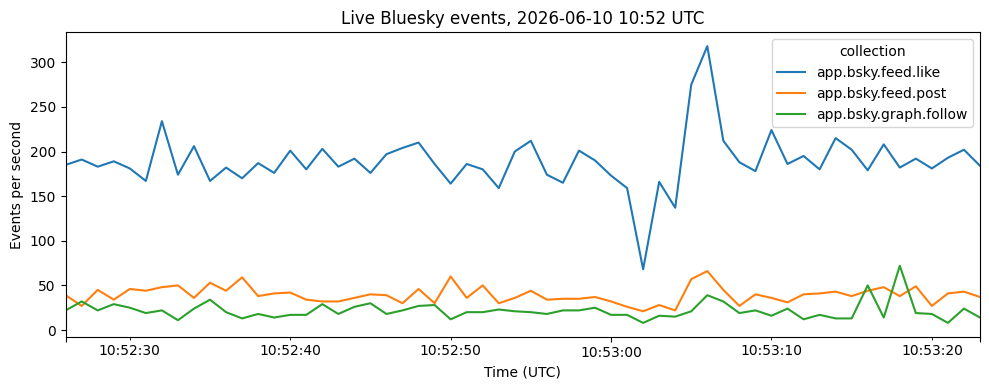

In [9]:
per_second = (
    events_df
    .assign(second=events_df["timestamp"].dt.floor("s"))
    .groupby(["second", "collection"])
    .size()
    .unstack(fill_value=0)
)

# The first and last seconds are partial windows; drop them for clean rates
per_second = per_second.iloc[1:-1]

ax = per_second.plot(figsize=(10, 4), lw=1.5)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Events per second")
ax.set_title(f"Live Bluesky events, {collection_started:%Y-%m-%d %H:%M} UTC")
ax.legend(title="collection")
plt.tight_layout()

### Post-level features (without the posts)

For the posts specifically, `stream.py`'s `post_features()` extracts a deliberately minimal, **content-free** feature set from each newly created post: a pseudonymous author hash, the timestamp, the declared language, whether it is a reply, and whether it embeds media. No text. We can answer real questions about the live network — *what share of posting is conversation? what languages is the network speaking right now?* — without storing a single word anyone wrote.

In [10]:
posts_df = pd.DataFrame(
    [f for f in (post_features(e) for e in events) if f is not None]
)
posts_df["timestamp"] = pd.to_datetime(posts_df["timestamp_us"], unit="us", utc=True)
posts_df = posts_df.drop(columns="timestamp_us")

print(f"{len(posts_df):,} newly created posts in the window")
posts_df[["is_reply", "has_embed", "has_image"]].mean().round(3)

2,225 newly created posts in the window


is_reply     0.416
has_embed    0.373
has_image    0.161
dtype: float64

Typically half or more of new posts are **replies** — most "posting" is conversation, not broadcast — and a substantial minority carry an embed (images, video, links, or quoted posts).

What languages is the network speaking *right now*? The `langs` field is self-declared by the posting client, so treat it as a noisy indicator (Part 06 discusses language identification properly).

94% of posts are in the top-10 languages


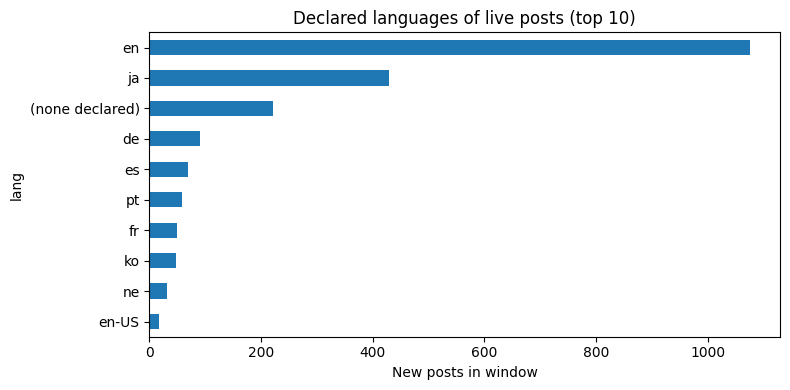

In [11]:
lang_counts = posts_df["lang"].fillna("(none declared)").value_counts()

ax = lang_counts.head(10)[::-1].plot.barh(figsize=(8, 4))
ax.set_xlabel("New posts in window")
ax.set_title("Declared languages of live posts (top 10)")
plt.tight_layout()

print(f"{lang_counts.head(10).sum() / lang_counts.sum():.0%} of posts are in the top-10 languages")

## 4. From one minute to the whole network

A back-of-the-envelope extrapolation: if the network kept this minute's pace for 24 hours, how many events would that be? (It will not keep this exact pace — Part 05 showed strong diurnal rhythms, so a single minute over- or under-shoots depending on when you collect. Treat these as order-of-magnitude estimates.)

In [12]:
rates = events_df["collection"].value_counts() / window_seconds

extrapolation = pd.DataFrame({
    "events_per_second": rates.round(2),
    "per_hour": (rates * 3_600).round(0).map("{:,.0f}".format),
    "per_day (extrapolated)": (rates * 86_400).round(0).map("{:,.0f}".format),
})
extrapolation

,events_per_second,per_hour,per_day (extrapolated)
collection,,,
app.bsky.feed.like,188.85,"679,875","16,317,008"
app.bsky.feed.post,39.62,"142,634","3,423,220"
app.bsky.graph.follow,21.44,"77,202","1,852,842"


### What a 1% sample would mean

For most of Twitter's research era, this back-of-the-envelope ran in the *other* direction. Researchers got the free "spritzer" Streaming API (~1% of tweets); the 10% "Decahose" and the full firehose were sold at prices most academics could not pay. Morstatter et al. (2013) compared the 1% stream against the firehose and found its coverage of hashtags, topics, and networks varied day to day and *not* at random — and Pfeffer, Mayer & Morstatter (2018) demonstrated that the sampling mechanism could be gamed to inject content into "random" samples.

Here is what a Twitter-style 1% sample of our own window would have given us:

In [13]:
sample_rate = 0.01
counts = events_df["collection"].value_counts()

one_percent = pd.DataFrame({
    "we observed (100%)": counts.map("{:,}".format),
    "a 1% sample would keep": (counts * sample_rate).round(0).astype(int),
})
print(one_percent)
print()
print(f"A 1% sample of this window would keep about "
      f"{int(len(posts_df) * sample_rate)} posts -- try estimating a "
      f"language distribution from that.")

                      we observed (100%)  a 1% sample would keep
collection                                                      
app.bsky.feed.like                11,149                     111
app.bsky.feed.post                 2,339                      23
app.bsky.graph.follow              1,266                      13

A 1% sample of this window would keep about 22 posts -- try estimating a language distribution from that.


On Bluesky the full stream is open to anyone, so the census is free and *sampling is a design choice you make and document yourself* — sample by time window, by account panel (`wantedDids`), or by random hash of the DID — rather than an opaque platform decision made for you. That is a quiet but profound improvement in research infrastructure.

## 5. Data minimization in practice

We just held ~10,000 live events in memory, including the full text of every post strangers wrote during our window. What should we *persist*?

The minimization principle from Part 01 applies with extra force to streams, because streams scale so easily: a notebook that saves "everything, just in case" turns into a multi-gigabyte archive of bystanders' content within hours. Our research questions in this notebook needed (1) event *rates* and (2) content-free post *features*. So that is all we save:

* **`data/stream_summary.csv`** — per-second event counts by collection. Pure aggregate; nobody is identifiable.
* **`data/stream_sample.csv`** — up to 200 post events with a *hashed* author identifier, timestamp, language, is-reply, and embed flags. **No post text, no URIs, no handles.**

Everything else gets garbage-collected when the kernel stops. If a future question needs more, collect again with the fields that question requires — the stream will still be flowing. (One more reason to prefer aggregates: users delete posts, and our saved files should not quietly resurrect what the network has forgotten.)

In [14]:
summary = per_second.copy()
summary.index.name = "second"
summary.to_csv("data/stream_summary.csv")

print(f"Saved data/stream_summary.csv: {summary.shape[0]} seconds x "
      f"{summary.shape[1]} collections")
summary.head()

Saved data/stream_summary.csv: 58 seconds x 3 collections


collection,app.bsky.feed.like,app.bsky.feed.post,app.bsky.graph.follow
second,,,
2026-06-10 10:52:26+00:00,185,39,22
2026-06-10 10:52:27+00:00,191,27,32
2026-06-10 10:52:28+00:00,183,45,22
2026-06-10 10:52:29+00:00,189,34,29
2026-06-10 10:52:30+00:00,181,46,25


In [15]:
sample = (
    posts_df
    .sample(n=min(200, len(posts_df)), random_state=42)
    .sort_values("timestamp")
    [["author_hash", "timestamp", "lang", "is_reply", "has_embed", "has_image"]]
)
sample.to_csv("data/stream_sample.csv", index=False)

print(f"Saved data/stream_sample.csv: {len(sample)} rows")
sample.head()

Saved data/stream_sample.csv: 200 rows


,author_hash,timestamp,lang,is_reply,has_embed,has_image
18,52533e6ef695,2026-06-10 10:52:25.910126+00:00,en,True,False,False
29,563fc8312707,2026-06-10 10:52:26.200892+00:00,ja,False,True,True
44,f611fff0a672,2026-06-10 10:52:26.623150+00:00,en,False,False,False
51,cc926ec6238c,2026-06-10 10:52:26.815079+00:00,en,False,True,True
67,7afd292c2a98,2026-06-10 10:52:27.304743+00:00,en,True,False,False


A reproducibility note to keep alongside any streaming archive: **record the collection window and parameters.** Ours are in this notebook's outputs — collection start time, duration, the `wantedCollections` filter, and the Jetstream instance — which is what another researcher needs to understand (if not exactly reproduce) a sample of a stream that never repeats itself.

## 6. The raw firehose: `com.atproto.sync.subscribeRepos`

Jetstream is a convenience layer *operated by someone else*. The protocol-native stream is the relay firehose, `com.atproto.sync.subscribeRepos`, and sometimes you need it:

* **Full fidelity and verifiability.** The firehose carries the actual signed commits, so you can cryptographically verify that events are authentic — Jetstream asks you to trust its operator.
* **Everything, not just app.bsky.** New lexicons and non-Bluesky applications on ATProto appear in the firehose by definition.
* **Account and identity events** with complete detail, plus the commit structure itself (useful for keeping a full mirror of repositories).
* **Independence.** If the Jetstream service changes, rate-limits, or disappears, the firehose is the protocol-guaranteed interface.

The cost is decoding: frames arrive as binary **CBOR** (a compact JSON-like format), and the records inside each commit travel as a **CAR** (Content Addressable aRchive) file you must unpack. The atproto SDK does the heavy lifting via `FirehoseSubscribeReposClient`. The cell below builds a complete handler so you can see the shape of that code, but does **not** call `.start()` — the firehose carries *every* event on the network (no server-side collection filters!) and a started client runs until you stop it.

In [16]:
from atproto import (CAR, FirehoseSubscribeReposClient,
                     parse_subscribe_repos_message)
from atproto import models as at_models

firehose = FirehoseSubscribeReposClient()

def on_message(message):
    """Decode one firehose frame into its created/deleted records."""
    commit = parse_subscribe_repos_message(message)  # CBOR -> typed model
    if not isinstance(commit, at_models.ComAtprotoSyncSubscribeRepos.Commit):
        return  # identity/account/info frames also flow past here
    if not commit.blocks:
        return
    car = CAR.from_bytes(commit.blocks)  # records travel as a CAR archive
    for op in commit.ops:
        # op.path is "<collection>/<rkey>", e.g. "app.bsky.feed.post/3l..."
        if op.action == "create" and op.cid is not None:
            record = car.blocks.get(op.cid)  # the decoded record dict
        elif op.action == "delete":
            pass  # deletes carry only the path; the record itself is gone

# firehose.start(on_message)   # <-- runs until stopped; NOT executed here

print("Firehose client constructed and handler defined (not started).")
print("Compare: ~10 lines of decoding that Jetstream does for us.")

Firehose client constructed and handler defined (not started).
Compare: ~10 lines of decoding that Jetstream does for us.


## 7. Building a bot: closing the loop

So far this series has only ever *read*. A **bot** combines reading (a trigger: a mention, a hashtag, a schedule) with the write endpoints from Part 00 (`send_post`, replies). Our part-specific module `bot.py` implements the smallest responsible design — a **mention-triggered reply bot** — as five composable pieces:

1. `check_notifications(client)` — polls `app.bsky.notification.list_notifications`. Notifications are private to the account, so this **requires authentication**; it is also the gentlest trigger, because people opt in by mentioning you.
2. `filter_mentions(notifications)` — keeps only `reason == "mention"`.
3. `build_reply(text)` — a *pure function* from mention text to reply text (or `None` to stay silent). All the bot's "personality" lives here, testable without any network.
4. `reply_refs(notification)` — builds the `ReplyRef` that threads the reply correctly.
5. `run_bot_once(client)` — one polling cycle, with **deduplication** (a persisted set of already-answered notification URIs) and **rate limiting** (a cap per cycle, a pause between sends). It defaults to `dry_run=True`.

Because `build_reply` is pure, we can exercise the bot's whole brain right now, unauthenticated:

In [17]:
from bot import (check_notifications, filter_mentions, build_reply,
                 reply_refs, run_bot_once,
                 MAX_REPLIES_PER_RUN, SECONDS_BETWEEN_REPLIES)

# The bot's entire decision logic, no network required:
print(build_reply("hey @examplebot.bsky.social ping"))
print("---")
print(build_reply("lovely weather today"))  # None: silence is a feature

pong! (2026-06-10 10:53:28 UTC)

[I am an automated account: bot run by @brianckeegan.com]
---
None


Two design choices to notice. First, the reply **discloses that it is a bot** — that string is appended to every reply, and the same statement belongs in the bot account's display name and bio. Second, the bot ignores everything that is not its one command. A bot that replies to everything is indistinguishable from spam.

### Threading a reply: `ReplyRef`

A Bluesky reply record carries two *strong references* (URI + CID pairs): **`parent`** is the post being answered, and **`root`** is the first post of the thread (Part 04 used this same structure to reconstruct reply trees). `reply_refs()` handles both cases: if the mention is itself a reply we reuse its root so our answer lands in the same thread; if the mention is a top-level post, it is its own root. The actual send is then one call:

```python
client.send_post(text=reply_text, reply_to=reply_refs(mention))
```

### Reading the bot's inbox

Notifications require authentication, so the next cells guard themselves with `is_authenticated(client)` — in an unauthenticated session they explain what they *would* do. This notebook never sends a post either way: `run_bot_once` defaults to `dry_run=True`, which prints instead of posting.

In [18]:
if is_authenticated(client):
    notifications = check_notifications(client, limit=25)
    reasons = pd.Series([n.reason for n in notifications])
    print(f"{len(notifications)} recent notifications:")
    print(reasons.value_counts())
    print(f"{len(filter_mentions(notifications))} are mentions")
else:
    print("Requires authentication: notifications are private to the account.")
    print("With an atproto.json (see Part 00), this cell would list the 25")
    print("most recent notifications and tally their reasons (mention, reply,")
    print("like, follow, repost, quote) -- mentions are the bot's trigger.")

Requires authentication: notifications are private to the account.
With an atproto.json (see Part 00), this cell would list the 25
most recent notifications and tally their reasons (mention, reply,
like, follow, repost, quote) -- mentions are the bot's trigger.


In [19]:
if is_authenticated(client):
    # One full polling cycle. dry_run=True prints what it WOULD send;
    # only ever set dry_run=False on a clearly-disclosed bot account.
    run_bot_once(client, dry_run=True)
else:
    print("Requires authentication: run_bot_once(client, dry_run=True) would")
    print("(1) poll notifications, (2) keep unanswered mentions, (3) build a")
    print("reply for each one containing 'ping', and (4) print the replies it")
    print("would send -- with at most", MAX_REPLIES_PER_RUN, "replies per cycle and",
          SECONDS_BETWEEN_REPLIES, "seconds")
    print("between sends. Deduplication is persisted to")
    print("data/answered_notifications.json so restarts never double-reply.")

Requires authentication: run_bot_once(client, dry_run=True) would
(1) poll notifications, (2) keep unanswered mentions, (3) build a
reply for each one containing 'ping', and (4) print the replies it
would send -- with at most 5 replies per cycle and 5.0 seconds
between sends. Deduplication is persisted to
data/answered_notifications.json so restarts never double-reply.


### Scheduling the bot

`run_bot_once` is deliberately a *single* cycle so that the scheduler lives outside your code. Polling once a minute via `cron` is gentle, debuggable, and plenty fast for a mention bot — you rarely need streaming latency for conversation. A tiny runner script:

```python
# run_bot.py
from bsky_client import get_client
from bot import run_bot_once

run_bot_once(get_client(), dry_run=False)  # disclosed bot account only!
```

and a crontab entry that runs it every minute, logging output:

```cron
* * * * * cd /home/you/pingbot && /usr/bin/python3 run_bot.py >> bot.log 2>&1
```

**Variant: a scheduled posting bot.** Many beloved bots have no trigger at all — they just post on a schedule (an hourly artwork, a daily statistic). That is the same pattern minus the notification polling:

```python
# daily_post.py
from bsky_client import get_client, is_authenticated

client = get_client()
if is_authenticated(client):
    client.send_post("Today's Bluesky stat: ... [automated post]")
```

```cron
0 9 * * * cd /home/you/dailybot && /usr/bin/python3 daily_post.py >> bot.log 2>&1
```

For an event-driven bot (e.g., responding to a hashtag the moment it appears), combine this part's two halves: a Jetstream consumer filtered to `app.bsky.feed.post` that watches for the trigger and calls the same send logic — with the same deduplication and rate limiting.

### Write rate limits: the points system

Bluesky PDS hosts meter *writes* with a points system: a record **create costs 3 points**, an **update 2**, a **delete 1**, with budgets of **5,000 points per hour** and **35,000 points per day** per account — roughly 1,666 creates per hour. Those are hard ceilings for spam control, not targets: our bot's self-imposed limits (`MAX_REPLIES_PER_RUN = 5` per cycle, a sleep between sends) keep it orders of magnitude below them, which is where a research bot belongs. There are also per-IP and per-session request limits (Part 01 covered reading politely with backoff).

### What your bot must never do

Ferrara et al. (2016) chronicle how *social bots* — automated accounts that imitate humans — polluted Twitter: inflating follower counts, astroturfing political hashtags, spreading misinformation, and contaminating a decade of research samples. The norms below are the difference between a community resource and a pest:

* **Never impersonate a human.** Disclose automation in the bio, display name, *and* the posts themselves.
* **Never interact uninvited at scale.** Reply when mentioned, post to your own timeline; do not cold-reply to strangers, mass-follow, or mass-like.
* **Respect blocks and mutes immediately**, honor deletion, and provide a human contact in the bio.
* **Never manufacture consensus** — no coordinated amplification, no astroturfing, no engagement farming.
* **Mind the platform's norms**: Bluesky's community guidelines require labeling automated accounts, and bot accounts that annoy people get blocked, reported, and defederated from feeds.

## 8. Research designs with streams

What does real-time access buy a researcher that Parts 01–09 could not?

* **Breaking-event monitoring.** When news breaks, retrospective search will later show you the surviving posts; a stream you started *beforehand* captures the full arc — including the posts that get deleted as the story develops, often the most analytically interesting ones. Standing collectors (e.g., Jetstream filtered to `app.bsky.feed.post`, watching for event keywords) are the streaming analogue of the event-study designs in Part 05, and they require you to specify the design *before* the data exist — a natural pre-registration.
* **Population-level measurement.** Because the stream is the census, base rates are actually computable: posts per day, the reply share, language composition, like-to-post ratios. On Twitter, every one of those numbers depended on an opaque platform sample that Morstatter et al. (2013) showed was biased and Pfeffer, Mayer & Morstatter (2018) showed was manipulable. Here you can *compute* the sampling properties of any cheaper design (a 1% hash sample, a panel of DIDs) against the full stream — sampling becomes a documented researcher choice instead of a platform secret.
* **Panel designs.** `wantedDids` turns Jetstream into a real-time panel study: follow up to 10,000 consented or public-figure accounts and observe posting, liking, and following behavior with second-level timestamps.
* **Bots as instruments.** Beyond mischief, disclosed bots have a research lineage: field experiments on social contagion and norm enforcement used bot accounts as randomized treatments. Any such design needs IRB review, disclosure, and debriefing — humans on the other end have not consented to be subjects.

## Ethics and limitations

**Bots interact with people who never signed up for a study.** Automated accounts must disclose that they are automated — in the bio, in the display name, and in the posts themselves — and should act only when invited (a mention) or in their own space (their timeline). If a bot is part of a research design, that design needs informed-consent thinking and institutional review, not just rate limiting; Ferrara et al. (2016) document the damage undisclosed bots did to both Twitter's users and Twitter research.

**Streams make over-collection effortless, so minimize by design.** This notebook held thousands of strangers' posts in memory but persisted only per-second aggregates and a 200-row, content-free, pseudonymized feature sample. That is the pattern to copy: decide what the research question needs *before* the collector runs, store aggregates and derived features rather than content, hash identifiers you do not need, record the collection window and parameters, and let everything else evaporate with the kernel. Remember that hashing is pseudonymization, not anonymization, and that saved archives should honor deletions the network has processed since.

**Limitations.** A one-minute window is a snapshot, not an estimate — diurnal and event-driven variation swamp any single window, so monitoring designs need long or repeated collections. Jetstream is a convenience service: it can lag, drop, or change, and it strips the cryptographic verifiability of raw commits (use `subscribeRepos` when fidelity matters; reconnect logic and cursor replay matter for production collectors). Self-declared `langs` labels are noisy. And Bluesky's population is not "the public": extrapolated daily volumes describe this network, not social media in general.

## References

* Morstatter, F., Pfeffer, J., Liu, H., & Carley, K. M. (2013). Is the sample good enough? Comparing data from Twitter's Streaming API with Twitter's Firehose. *Proceedings of the International AAAI Conference on Web and Social Media*, 7(1), 400–408. [https://doi.org/10.1609/icwsm.v7i1.14401](https://doi.org/10.1609/icwsm.v7i1.14401)
* Pfeffer, J., Mayer, K., & Morstatter, F. (2018). Tampering with Twitter's sample API. *EPJ Data Science*, 7, 50. [https://doi.org/10.1140/epjds/s13688-018-0178-0](https://doi.org/10.1140/epjds/s13688-018-0178-0)
* Ferrara, E., Varol, O., Davis, C., Menczer, F., & Flammini, A. (2016). The rise of social bots. *Communications of the ACM*, 59(7), 96–104. [https://doi.org/10.1145/2818717](https://doi.org/10.1145/2818717)

**Documentation**

* Jetstream announcement and design: [https://docs.bsky.app/blog/jetstream](https://docs.bsky.app/blog/jetstream); service repository: [https://github.com/bluesky-social/jetstream](https://github.com/bluesky-social/jetstream)
* Firehose (`com.atproto.sync.subscribeRepos`): [https://docs.bsky.app/docs/advanced-guides/firehose](https://docs.bsky.app/docs/advanced-guides/firehose)
* PDS rate limits (the points system): [https://docs.bsky.app/blog/rate-limits-pds-v3](https://docs.bsky.app/blog/rate-limits-pds-v3)
* atproto SDK firehose examples: [https://atproto.blue/en/latest/atproto_firehose/index.html](https://atproto.blue/en/latest/atproto_firehose/index.html)